<a href="https://colab.research.google.com/github/zozbe/agricultural-water-footprint-analysis/blob/main/water_footprint_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1) Gerekli kütüphanelerin yüklenmesi
# Veri analizi, görselleştirme ve dosya işlemleri için kütüphaneleri import ediyoruz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
# Görselleştirme ayarları
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
uploaded = files.upload()
for fn in uploaded.keys():
    print(f"File '{fn}' uploaded.")

Saving agricultural_water_footprint.csv to agricultural_water_footprint (1).csv
File 'agricultural_water_footprint (1).csv' uploaded.


In [ ]:
# 2) Veri setinin yüklenmesi
# Colab ortamına CSV dosyamızı yüklüyoruz
df=pd.read_csv("agricultural_water_footprint.csv")

In [ ]:
# 3) Veri seti hakkında genel bilgiler
print("İlk 5 Satır:")
print(df.head())  # Veri önizleme
print("\nVeri Seti Bilgisi:")
print(df.info())  # Veri tipleri ve null değer kontrolü
print("\nEksik Değer Kontrolü:")
print(df.isnull().sum())


İlk 5 Satır:
       Crop  Water Use (m³/kg) Irrigation Type        Climate  \
0   Bananas               5557            Drip           Arid   
1  Pumpkins               8024           Flood           Arid   
2    Grapes               1540             NaN    Continental   
3     Plums                826           Flood           Arid   
4    Apples               2104       Sprinkler  Mediterranean   

   Yield (tons/ha) Water-Saving Practices  \
0             5.14   Efficient Irrigation   
1             4.44               Mulching   
2             4.01             Crop Cover   
3             5.08               Mulching   
4             5.83               Mulching   

   Water Pollution (Grey Water) (m³/kg) Soil Type Water Scarcity  \
0                                   716     Loamy         Severe   
1                                   969    Clayey         Severe   
2                                   437     Sandy            Low   
3                                   231     Loamy    

In [ ]:
# 4) Eksik değerlerin doldurulması
# Sayısal kolonlar → median ile dolduruyoruz (uç değerlerden daha az etkilenir)
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
# Kategorik kolonlar → mode (en sık görülen değer) ile dolduruyoruz
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Tekrar kontrol
print("\nTemizlenmiş Veri Eksik Değer Kontrolü:")
print(df.isnull().sum())


Temizlenmiş Veri Eksik Değer Kontrolü:
Crop                                    0
Water Use (m³/kg)                       0
Irrigation Type                         0
Climate                                 0
Yield (tons/ha)                         0
Water-Saving Practices                  0
Water Pollution (Grey Water) (m³/kg)    0
Soil Type                               0
Water Scarcity                          0
Post-Harvest Processing (Liters/kg)     0
Fertilizer Use (kg/ha)                  0
Pesticide Use (kg/ha)                   0
Organic Practices                       0
Green Water Use (m³/kg)                 0
Blue Water Use (m³/kg)                  0
Crop Cycle Duration (days)              0
Harvest Season                          0
Temperature Requirement (°C)            0
Rainfall Requirement (mm/year)          0
CO2 Emission (kg/ha)                    0
Land Use (ha/kg)                        0
Crop Rotation Practices                 0
Average Farm Size (ha)              

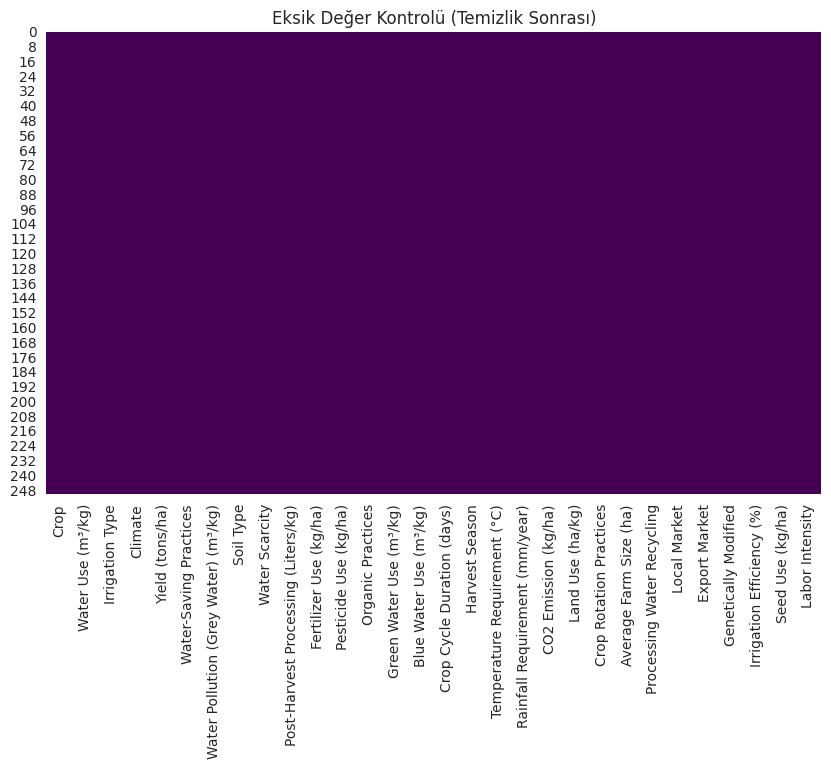

In [ ]:
# 5) Eksik değer görselleştirme (temizlik sonrası)
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Eksik Değer Kontrolü (Temizlik Sonrası)")
plt.show()


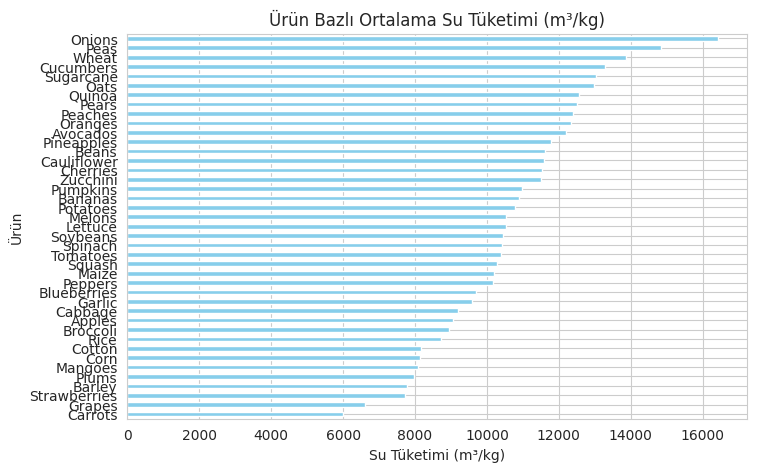

In [ ]:
# 6) Ürün bazlı ortalama su tüketimi
urun_tuketim = df.groupby("Crop")["Water Use (m³/kg)"].mean().sort_values()

plt.figure(figsize=(8,5))
urun_tuketim.plot(kind="barh", color="skyblue")
plt.title("Ürün Bazlı Ortalama Su Tüketimi (m³/kg)")
plt.xlabel("Su Tüketimi (m³/kg)")
plt.ylabel("Ürün")
plt.show()

# Yorum: Burada her ürünün ortalama su tüketimini karşılaştırıyoruz.
# Daha az su tüketen ürünler sürdürülebilir tarım için avantajlıdır.

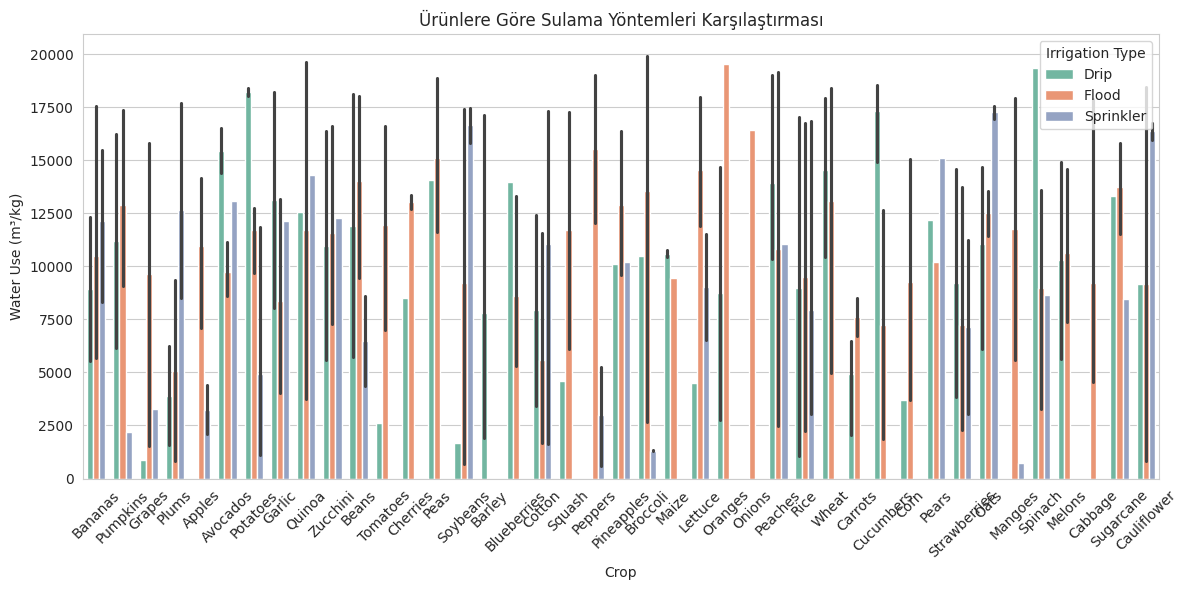

In [ ]:
# 7) Ürünlere göre sulama yöntemleri karşılaştırması
plt.figure(figsize=(12,6))
sns.barplot(data=df, x="Crop", y="Water Use (m³/kg)", hue="Irrigation Type", dodge=True, width=0.7)
plt.title("Ürünlere Göre Sulama Yöntemleri Karşılaştırması")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Yorum: Aynı ürün farklı sulama tiplerinde farklı miktarda su tüketiyor.
# Bu da sulama yönteminin ne kadar önemli olduğunu gösteriyor.


İklime Göre Ortalama Su Kullanımı:
               Water Use (m³/kg)  Blue Water Use (m³/kg)  \
Climate                                                    
Mediterranean       11647.851064             9220.510638   
Continental         11303.690476             7520.738095   
Arid                10624.024390             7106.731707   
Semi-arid           10061.227273             7181.431818   
Tropical             9829.527778             8407.638889   
Temperate            9310.250000             7263.750000   

               Green Water Use (m³/kg)  
Climate                                 
Mediterranean              2528.808511  
Continental                2822.095238  
Arid                       2705.000000  
Semi-arid                  2702.909091  
Tropical                   2947.944444  
Temperate                  2559.975000  


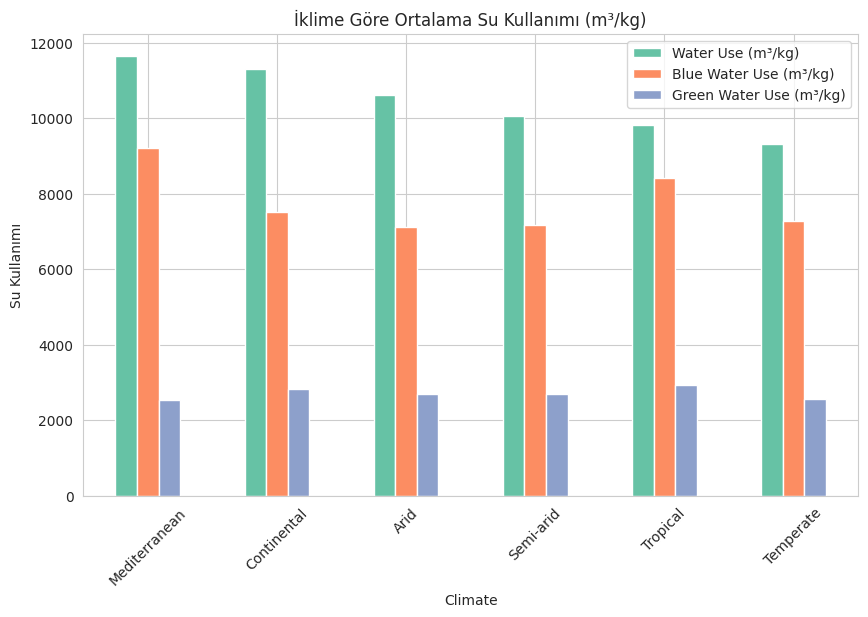

In [ ]:
# 8) İklime göre ortalama su ayak izi
climate_stats = df.groupby("Climate")[["Water Use (m³/kg)", "Blue Water Use (m³/kg)", "Green Water Use (m³/kg)"]].mean().sort_values("Water Use (m³/kg)", ascending=False)
print("\nİklime Göre Ortalama Su Kullanımı:")
print(climate_stats)

climate_stats.plot(kind='bar', figsize=(10,6))
plt.title("İklime Göre Ortalama Su Kullanımı (m³/kg)")
plt.ylabel("Su Kullanımı")
plt.xticks(rotation=45)
plt.show()

# Yorum: İklim koşulları su tüketimini ciddi oranda etkiliyor.
# Kurak iklimlerde su tüketimi doğal olarak daha yüksek çıkıyor.


Su Tasarrufu Pratikleri ve Ortalama Su Kullanımı:
                        Water Use (m³/kg)  \
Water-Saving Practices                      
Crop Cover                    9566.918033   
Efficient Irrigation         10509.350000   
Mulching                     10950.488372   

                        Water Pollution (Grey Water) (m³/kg)  
Water-Saving Practices                                        
Crop Cover                                        538.131148  
Efficient Irrigation                              550.166667  
Mulching                                          564.248062  


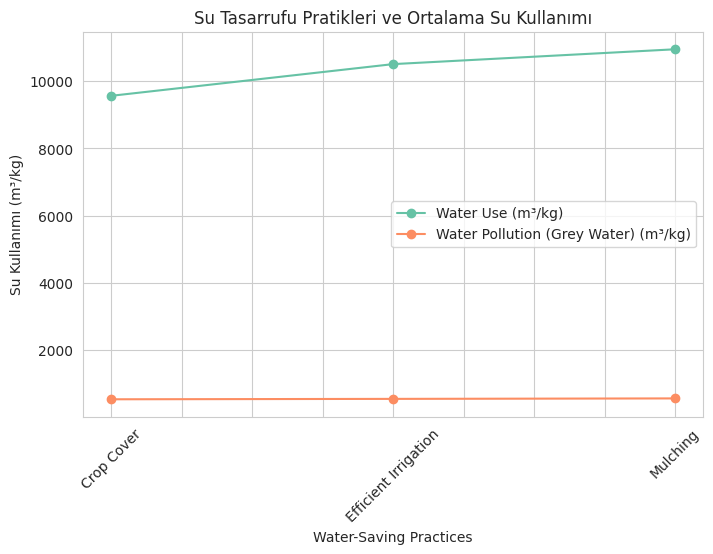

In [ ]:
# 9) Su tasarrufu pratiklerine göre su kullanımı
saving_stats = df.groupby("Water-Saving Practices")[["Water Use (m³/kg)", "Water Pollution (Grey Water) (m³/kg)"]].mean().sort_values("Water Use (m³/kg)")
print("\nSu Tasarrufu Pratikleri ve Ortalama Su Kullanımı:")
print(saving_stats)

saving_stats.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Su Tasarrufu Pratikleri ve Ortalama Su Kullanımı")
plt.ylabel("Su Kullanımı (m³/kg)")
plt.xticks(rotation=45)
plt.show()

# Yorum: Su tasarrufu yöntemleri su tüketiminde belirgin düşüş sağlıyor.
# Bu da sürdürülebilir tarım için önemli bir uygulama.


Yüksek Verimli Mahsullerin Ortalama Su Kullanımı:
Crop
Cotton           5312.500000
Mangoes          5594.000000
Plums            6501.000000
Carrots          7386.500000
Grapes           8338.500000
Peppers          8512.250000
Strawberries     8625.000000
Blueberries      9121.000000
Corn             9264.000000
Rice             9779.333333
Lettuce          9847.250000
Apples          10005.833333
Maize           10417.000000
Barley          10711.000000
Potatoes        10739.800000
Cherries        10939.500000
Cauliflower     11146.000000
Pineapples      11421.500000
Cabbage         11524.000000
Garlic          11638.000000
Bananas         11695.250000
Squash          11728.000000
Soybeans        11844.333333
Melons          12142.666667
Peaches         12396.333333
Sugarcane       12855.500000
Pumpkins        12864.400000
Avocados        13036.000000
Wheat           13349.000000
Pears           13637.000000
Oats            14037.000000
Tomatoes        14302.000000
Spinach         

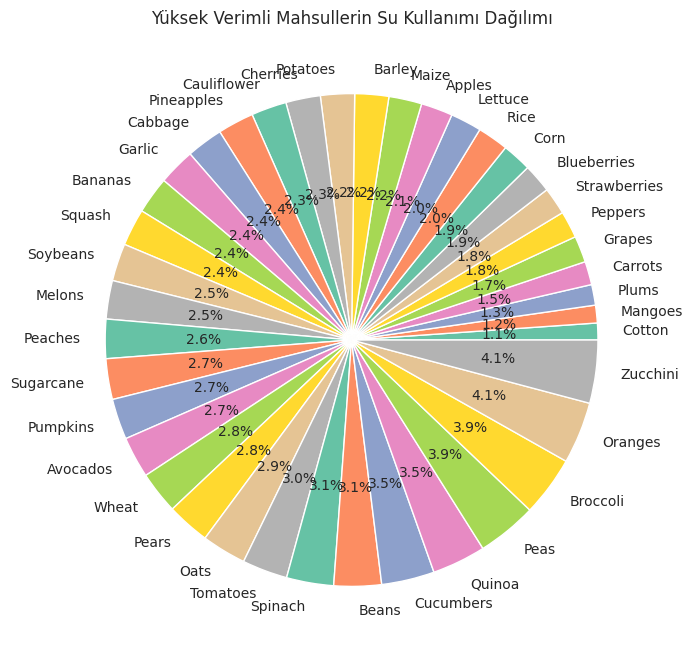

In [ ]:
# 10) Yüksek verimli mahsuller (ortalamanın üstünde verim sağlayanlar)
avg_yield = df["Yield (tons/ha)"].mean()
high_yield = df[df["Yield (tons/ha)"] > avg_yield]
high_yield_stats = high_yield.groupby("Crop")["Water Use (m³/kg)"].mean().sort_values()

print("\nYüksek Verimli Mahsullerin Ortalama Su Kullanımı:")
print(high_yield_stats)

high_yield_stats.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title("Yüksek Verimli Mahsullerin Su Kullanımı Dağılımı")
plt.ylabel("")
plt.show()

# Yorum: Verimi yüksek olan mahsullerin su tüketim dağılımını inceliyoruz.
# Bu grafik hangi ürünlerin daha verimli ve daha az su ile yetiştirilebildiğini gösteriyor.

In [ ]:
# 11) Özet tablo oluşturma ve kaydetme
summary = df.groupby("Crop").agg({
    "Water Use (m³/kg)": "mean",
    "Yield (tons/ha)": "mean",
    "Blue Water Use (m³/kg)": "mean"
}).sort_values("Water Use (m³/kg)", ascending=False)

print("\nÖzet Tablo:")
print(summary)
summary.to_csv("summary_water_footprint.csv")
#Su kullanımına göre azalan sırada sıralıyoruz, böylece en fazla su tüketen ürünleri başta görebiliyoruz



Özet Tablo:
              Water Use (m³/kg)  Yield (tons/ha)  Blue Water Use (m³/kg)
Crop                                                                    
Onions             16423.000000         2.390000            10991.000000
Peas               14847.750000         4.070000            11221.250000
Wheat              13876.444444         6.778889             7325.444444
Cucumbers          13288.800000         5.964000             9684.600000
Sugarcane          13026.375000         6.355000             7589.875000
Oats               12973.375000         4.850000             7895.875000
Quinoa             12556.750000         5.707500             5873.750000
Pears              12492.333333         7.936667             8672.666667
Peaches            12396.333333         7.941667            10898.666667
Oranges            12328.666667         3.600000             8092.333333
Avocados           12207.166667         5.068333             4297.000000
Pineapples         11790.200000       

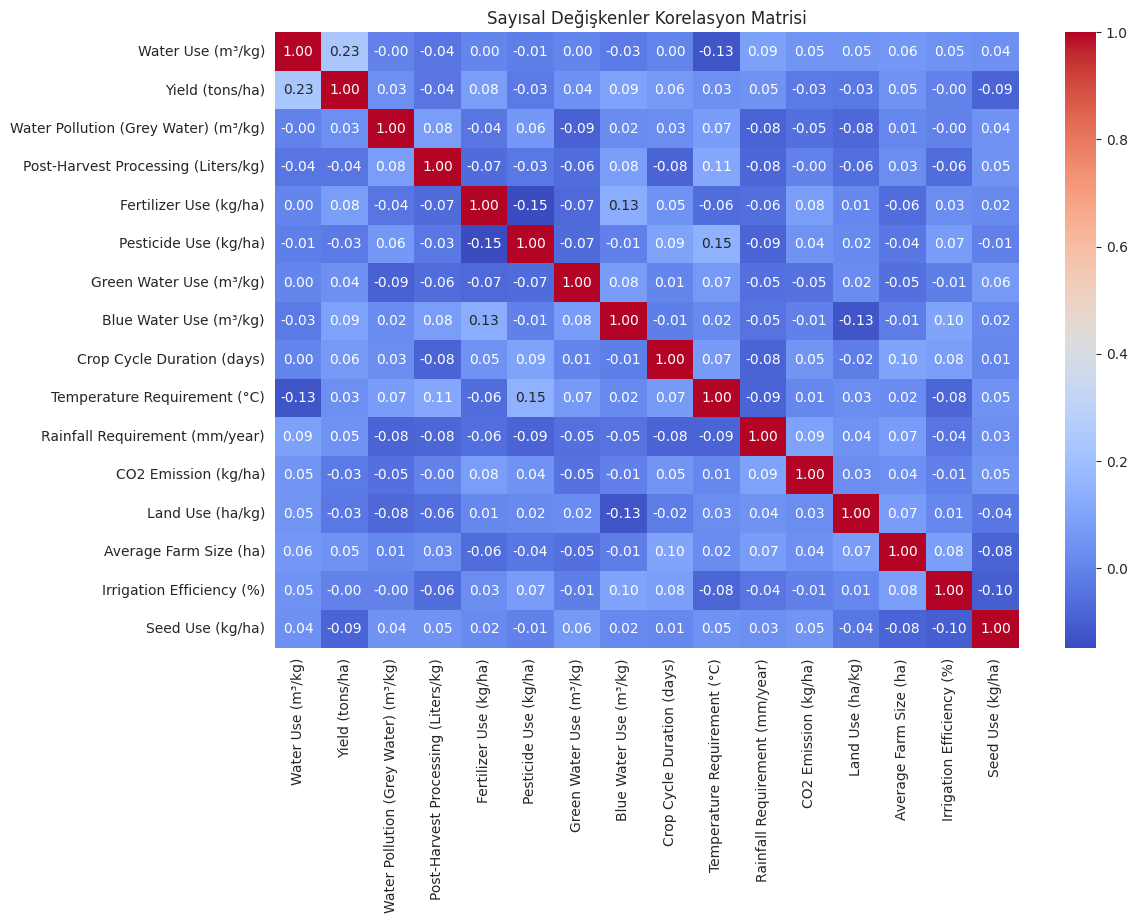

In [ ]:
# 12) Korelasyon matrisi
numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numerical_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Sayısal Değişkenler Korelasyon Matrisi")
plt.show()
# Yorum: Burada değişkenler arasındaki ilişkileri görüyoruz.
# Örneğin su kullanımı ile verim arasında güçlü/zayıf korelasyon olup olmadığını buradan yorumlayabiliyoruz.
